<a href="https://colab.research.google.com/github/Ainun-Haseeb/Coursera_Machine_learning/blob/main/ANN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/students_grades_placement (1).csv'
df = pd.read_csv(file_path)

In [ ]:
Features = [f'Course_{i}' for i in range(1, 41)] + ['Branch', 'Six_Month_Internship', 'CGPA', 'Average_CTC']

In [ ]:
X = df[Features]
y = df['Placed']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# 3. Define ANN model
model = MLPClassifier(hidden_layer_sizes=(8, 6),   # Two hidden layers
                      activation='logistic',             # activation
                      solver='adam',                 # Adam optimizer (backprop-based)
                      learning_rate_init=0.01,       # Learning rate
                      max_iter=500,                  # Number of epochs
                      random_state=42)

In [ ]:
# Calculate mean of training features, ignoring NaNs
mean_values = X_train.mean()

# Fill NaN values in training and testing sets using the calculated means
X_train_imputed = X_train.fillna(mean_values)
X_test_imputed = X_test.fillna(mean_values)

# Fit the model with the imputed data
model.fit(X_train_imputed, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(8, 6),
              learning_rate_init=0.01, max_iter=500, random_state=42)

In [ ]:
y_pred = model.predict(X_test_imputed)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.945

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       204
           1       0.98      0.93      0.96       396

    accuracy                           0.94       600
   macro avg       0.93      0.95      0.94       600
weighted avg       0.95      0.94      0.95       600



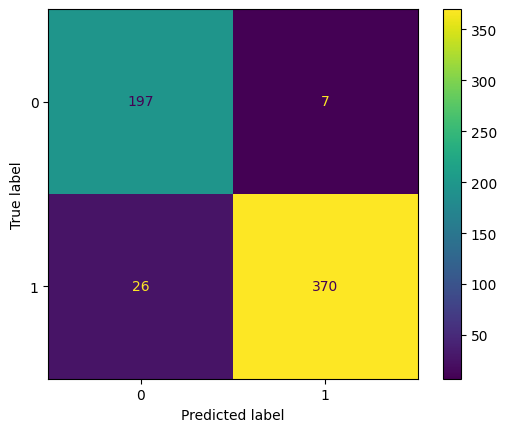

In [ ]:
# 7. Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_imputed, y_test)